# BEE 4750 Homework 3: Dissolved Oxygen and Monte Carlo

**Name**: Sarah Vafiadis, Nathan Rhoads

**ID**: sv439

> **Due Date**
>
> Thursday, 10/16/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to implement a model for dissolved oxygen in a
    river with multiple waste releases and use this to develop a
    strategy to ensure regulatory compliance.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [26]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Documents/GitHub/hw3-sarah-nathan-1`


In [27]:
using Random
using Plots
using LaTeXStrings
using Distributions

## Problems (Total: 30 Points)

### Problem 1 (30 points)

A river which flows at 6 km/d is receiving waste discharges from two
sources which are 15 km apart. The oxygen reaeration rate is 0.55
day<sup>-1</sup>, and the decay rates of CBOD and NBOD are are 0.35 and
0.25 day<sup>-1</sup>, respectively. The river’s saturated dissolved
oxygen concentration is 10m g/L.

If the characteristics of the river inflow and waste discharges are
given in <a href="#tbl-river" class="quarto-xref">Table 1</a>, write a
Julia model to compute the dissolved oxygen concentration from the first
wastewater discharge to an arbitrary distance `d` km downstream. Use
your model to compute the minimum dissolved oxygen concentration up to
50 km downstream and how far downriver this maximum occurs.

| Parameter | River Inflow | Waste Stream 1 | Waste Stream 2 |
|:--:|---:|---:|---:|
| Inflow | 100,000 m<sup>3</sup>/d | 10,000 m<sup>3</sup>/d | 15,000 m<sup>3</sup>/d |
| DO Concentration | 7.5 mg/L | 5 mg/L | 5 mg/L |
| CBOD | 5 mg/L | 50 mg/L | 45 mg/L |
| NBOD | 5 mg/L | 35 mg/L | 35 mg/L |

Table 1: River inflow and waste stream characteristics for Problem 1.

### Problem 1.1

Implement the Streeter-Phelps (analytic) solution for the dissolved
oxygen concentration. Plot the dissolved oxygen concentration from the
first waste stream to 50 km downriver. What is the minimum value in
mg/L?

Analytic Solution: Minimum DO = 3.76 mg/L at 22 km


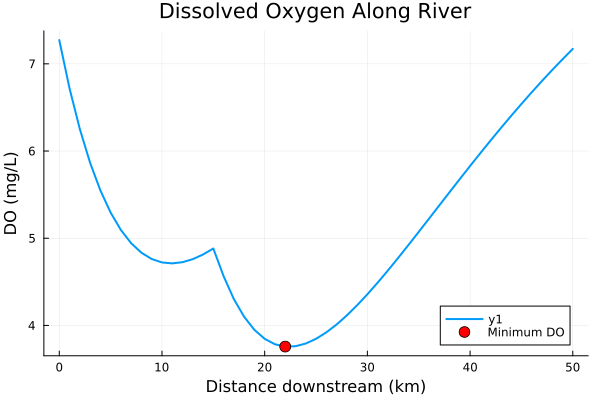

In [28]:
# Parameters
v = 6           # River velocity (km/d) 
Cs = 10         # Saturated DO concentration (mg/L)

ka = 0.55       # Reaeration rate (d^-1)
kc = 0.35       # CBOD decay rate (d^-1)
kn = 0.25       # NBOD decay rate (d^-1)

Qr = 100000     # River inflow (m^3/d)
Q1 = 10000      # Waste stream 1 (m^3/d)
Q2 = 15000      # Waste stream 2 (m^3/d)

DOr = 7.5       # DO concentration in river inflow (mg/L)
DO1 = 5         # DO concentration in waste stream 1 (mg/L)
DO2 = 5         # DO concentration in waste stream 2 (mg/L)

CBODr = 5       # CBOD concentration in river inflow (mg/L)
CBOD1 = 50      # CBOD concentration in waste stream 1 (mg/L)
CBOD2 = 45      # CBOD concentration in waste stream 2 (mg/L)

NBODr = 5       # NBOD concentration in river inflow (mg/L)
NBOD1 = 35      # NBOD concentration in waste stream 1 (mg/L)
NBOD2 = 35      # NBOD concentration in waste stream 2 (mg/L)

# Mixing at point 1
DO_0 = (Qr*DOr + Q1*DO1)  / (Qr+Q1)
CBOD_0 = (Qr*CBODr + Q1*CBOD1)  / (Qr+Q1)
NBOD_0 = (Qr*NBODr + Q1*NBOD1)  / (Qr+Q1)
Q_mix = Qr + Q1

function decay(x,U,C0,B0,N0)
    # x = distance d km downstream
    a1 = exp(-ka*x/U)
    a2 = ((kc/(ka-kc)) * (exp(-kc*x/U) - exp(-ka*x/U)))
    a3 = ((kn/(ka-kn)) * (exp(-kn*x/U) - exp(-ka*x/U)))
    Cx = Cs*(1-a1) + C0*a1 - B0*a2 - N0*a3
    return Cx                                               # DO concentration at distance x
end

# Values at 15 km before mixing
DO_first = decay(15, v, DO_0, CBOD_0, NBOD_0)
CBOD_first = CBOD_0 * exp(-kc * 15 / v)
NBOD_first  = NBOD_0  * exp(-kn * 15 / v)

# Mixing with wastewater stream 2
DO_1 = (Q_mix*DO_first + Q2*DO2)  / (Q_mix + Q2)
NBOD_1 = (Q_mix*NBOD_first + Q2*NBOD2)  / (Q_mix + Q2)
CBOD_1 = (Q_mix*CBOD_first + Q2*CBOD2)  / (Q_mix + Q2)

# Plot for 0 to 50 km
xs = 0:1:50
DO_vals = Float64[]

for i in xs
    if i <= 15
        push!(DO_vals, decay(i, v, DO_0, CBOD_0, NBOD_0))
    else
        push!(DO_vals, decay(i - 15, v, DO_1, CBOD_1, NBOD_1))
    end
end

# Identify and plot minimum DO
min_DO, index = findmin(DO_vals)
min_x = xs[index]

println("Analytic Solution: Minimum DO = $(round(min_DO, digits=2)) mg/L at $(min_x) km")

# plot the DO profile
plot(xs, DO_vals,
     xlabel="Distance downstream (km)",
     ylabel="DO (mg/L)",
     title="Dissolved Oxygen Along River",
     lw=2)

scatter!([min_x], [min_DO],
         color=:red,
         markersize=:6,
         label="Minimum DO")

### Problem 1.2

Implement a numerically-integrated (discretized) solution for the
dissolved oxygen concentration. Using a resolution of 0.5km, conduct a
simulation and plot the results on the same axis as the plot from
Problem 1.1. How has the minimum value changed? What do you attribute
this difference to (be specific about the source of the difference(s) in
terms of the simulation dynamics, not just that one is a numerical
approximation).

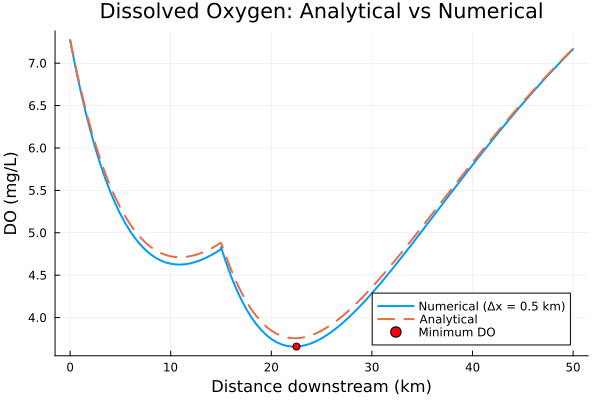

Minimum DO = 3.658 mg/L at x = 22.5 km


In [29]:
function DO_simulate(DO0, CBOD0, NBOD0, v, ka, kc, kn, Cs, Δx, xmax)
    nsteps = Int(xmax / Δx)
    xs = collect(0:Δx:xmax)
    DO = zeros(length(xs))
    CBOD = zeros(length(xs))
    NBOD = zeros(length(xs))

    DO[1] = DO0
    CBOD[1] = CBOD0
    NBOD[1] = NBOD0

    for i in 1:(nsteps)
        dDOdx = (ka/v)*(Cs - DO[i]) - (kc/v)*CBOD[i] - (kn/v)*NBOD[i]
        DO[i+1] = DO[i] + Δx * dDOdx
        CBOD[i+1] = CBOD[i] * exp(-kc*Δx/v)
        NBOD[i+1] = NBOD[i] * exp(-kn*Δx/v)
    end
    return xs, DO, CBOD, NBOD
end

# segment 1: 0–15 km - first waste stream
xs1, DO1_vals, CBOD1_vals, NBOD1_vals = DO_simulate(DO_0, CBOD_0, NBOD_0, v, ka, kc, kn, Cs, 0.5, 15)

# mixing at 15 km with waste stream 2
DO_15 = DO1_vals[end]
CBOD_15 = CBOD1_vals[end]
NBOD_15 = NBOD1_vals[end]

DO_mix2 = (Q_mix*DO_15 + Q2*DO2) / (Q_mix + Q2)
CBOD_mix2 = (Q_mix*CBOD_15 + Q2*CBOD2) / (Q_mix + Q2)
NBOD_mix2 = (Q_mix*NBOD_15 + Q2*NBOD2) / (Q_mix + Q2)

#Segment 2 15–50 km
xs2, DO2_vals, CBOD2_vals, NBOD2_vals = DO_simulate(DO_mix2, CBOD_mix2, NBOD_mix2, v, ka, kc, kn, Cs, 0.5, 35)

# Combine both reaches
xs_total = vcat(xs1, xs2 .+ 15)
DO_total = vcat(DO1_vals, DO2_vals)

xs_analytic = 0:0.5:50
DO_analytic = [x <= 15 ? decay(x, v, DO_0, CBOD_0, NBOD_0) :
                          decay(x - 15, v, DO_1, CBOD_1, NBOD_1) for x in xs_analytic]

xs_num = xs_total
DO_num = DO_total

#Plot both solutions
p = plot(xs_num, DO_num, lw=2, label="Numerical (Δx = 0.5 km)",
         xlabel="Distance downstream (km)", ylabel="DO (mg/L)",
         title="Dissolved Oxygen: Analytical vs Numerical")

plot!(p, xs_analytic, DO_analytic, lw=2, linestyle=:dash, label="Analytical")

# Identify and plot minimum DO in numerical solution
min_DO, idx = findmin(DO_num)
println("Minimum DO = $(round(min_DO, digits=3)) mg/L at x = $(xs_num[idx]) km")
scatter!(p, [xs_num[idx]], [min_DO], color=:red, label="Minimum DO")

display(p)

The minimum value of the numerical solution was less than the analytic solution by .102mg/L. The difference is caused by truncation error, which arises from using numerical methods to simply an analytical solution. The numerical solution was found through a first-order Taylor expansion, neglecting other order terms.

### Problem 1.3

Using the analytic model, what is the minimum level of treatment (%
removal of organic waste; assume this is equivalent to the same level of
reduction of the CBOD and NBOD) for waste stream 1 that will ensure that
the dissolved oxygen concentration is in compliance with the 4 mg/L
standard along with a 5% margin of safety, assuming that waste stream 2
remains untreated? How about if only waste stream 2 is treated?

In [30]:
function min_DO_for_treatment(treat1, treat2)
    # Apply treatment
    CBOD1_t = CBOD1 * treat1
    NBOD1_t = NBOD1 * treat1
    CBOD2_t = CBOD2 * treat2
    NBOD2_t = NBOD2 * treat2

    #mixing at point 1
    DO_0 = (Qr*DOr + Q1*DO1) / (Qr+Q1)
    CBOD_0 = (Qr*CBODr + Q1*CBOD1_t) / (Qr+Q1)
    NBOD_0 = (Qr*NBODr + Q1*NBOD1_t) / (Qr+Q1)
    Q_mix = Qr + Q1

    #Values at 15 km
    DO_first = decay(15, v, DO_0, CBOD_0, NBOD_0)
    CBOD_first = CBOD_0 * exp(-kc * 15 / v)
    NBOD_first = NBOD_0 * exp(-kn * 15 / v)

    #mixing with stream 2
    DO_1 = (Q_mix*DO_first + Q2*DO2) / (Q_mix + Q2)
    CBOD_1 = (Q_mix*CBOD_first + Q2*CBOD2_t) / (Q_mix + Q2)
    NBOD_1 = (Q_mix*NBOD_first + Q2*NBOD2_t) / (Q_mix + Q2)

    #compute DO values
    xs = 0:0.5:50
    DO_vals = [x <= 15 ? decay(x, v, DO_0, CBOD_0, NBOD_0) :
    decay(x - 15, v, DO_1, CBOD_1, NBOD_1) for x in xs]

    return minimum(DO_vals)
end

#Minimum treatment for stream 1 only
target = 4.2 # 4 times 1.05 for safety net target
treat1 = 1.0
while min_DO_for_treatment(treat1, 1.0) < target && treat1 > 0
    treat1 -= 0.01
end
println("Required treatment % for stream 1 only = $(round((1 - treat1)*100, digits=1))%")

#Find minimum treatment for stream 2 only
treat2 = 1.0
while min_DO_for_treatment(1.0, treat2) < target && treat2 > 0
    treat2 -= 0.01
end
println("Required treatment % for stream 2 only = $(round((1 - treat2)*100, digits=1))%")

Required treatment % for stream 1 only = 28.0%
Required treatment % for stream 2 only = 22.0%


### Problem 1.4

Suppose you are responsible for designing a waste treatment plan for
discharges into the river, with a regulatory mandate to keep the
dissolved oxygen concentration above 4 mg/L. Discuss whether you’d opt
to treat waste stream 2 alone or both waste streams equally. What other
information might you need to make a conclusion, if any?

While waste stream 1 experiences a larger "sag curve," bringing DO levels close to the regulatory standard, input of waste stream 2 is what actually causes DO levels to dip below 4 mg/L. By only treating waste stream 2, DO levels can be maintained above 4 mg/L. However, it would be important to observe longer-term behavior of the system before a final decision is made, as the largest drop in DO levels occurs after the release of waste stream 1 into the river. It would also be important to factor in treatment cost -- it may be more expensive to treat waste stream 1 since a much larger decrease in DO levels is experienced. If it is significantly cheaper to only treat waste stream 2, this may serve as a good "band-aid" solution, maintaining DO levels just above 4 mg/L.

### Problem 1.5

Suppose that it is known that the DO concentrations at the river inflow
can vary according to a $\text{LogNormal}(2.0, 0.15)$ distribution.
Conduct a Monte Carlo simulation of the DO concentration in the river.
If you treat only waste stream 1 (based on your analysis from Problem
1.3), what is the expected probability and 95% confidence interval that
the river fails to comply with the regulatory standard of 4 mg/L? How
did you decide that your Monte Carlo sample size was sufficiently large?

In [ ]:
using Distributions, Statistics, Plots

# Constants
v = 6           # River velocity (km/d)
Cs = 10         # Saturated DO concentration (mg/L)
ka = 0.55       # Reaeration rate (d^-1)
kc = 0.35       # CBOD decay rate (d^-1)
kn = 0.25       # NBOD decay rate (d^-1)

Qr = 100000     # River inflow (m^3/d)
Q1 = 10000      # Waste stream 1 (m^3/d)

DO1 = 5         # DO in waste stream 1 (mg/L)

CBODr = 5       # CBOD in river inflow (mg/L)
CBOD1 = 50      # CBOD in waste stream 1 (mg/L)

NBODr = 5       # NBOD in river inflow (mg/L)
NBOD1 = 35      # NBOD in waste stream 1 (mg/L)

# DO decay function
function decay(x, U, C0, B0, N0)
    a1 = exp(-ka*x/U)
    a2 = (kc/(ka-kc)) * (exp(-kc*x/U) - exp(-ka*x/U))
    a3 = (kn/(ka-kn)) * (exp(-kn*x/U) - exp(-ka*x/U))
    return Cs*(1 - a1) + C0*a1 - B0*a2 - N0*a3
end

# Monte Carlo parameters
N = 100000
threshold = 4.0
min_DO_vals = Float64[]

# Simulation
for _ in 1:N
    DOr_sample = rand(LogNormal(2.0, 0.15))  # Sample DO inflow

    # Mixed concentrations after waste stream 1
    DO_0 = (Qr*DOr_sample + Q1*DO1) / (Qr + Q1)
    CBOD_0 = (Qr*CBODr + Q1*CBOD1) / (Qr + Q1)
    NBOD_0 = (Qr*NBODr + Q1*NBOD1) / (Qr + Q1)

    # DO profile downstream
    DO_profile = [decay(x, v, DO_0, CBOD_0, NBOD_0) for x in 0:1:50]
    push!(min_DO_vals, minimum(DO_profile))
end

# Correct this part!
# Probability and confidence interval
p_fail = count(x -> x < threshold, min_DO_vals) / N
z = 1.96
margin = z * sqrt(p_fail * (1 - p_fail) / N)
lower = max(p_fail - margin, 0.0)
upper = min(p_fail + margin, 1.0)

println("Probability DO < 4 mg/L: $(round(p_fail, digits=4))")
println("95% Confidence Interval: [$(round(lower, digits=4)), $(round(upper, digits=4))]")


## References

List any external references consulted, including classmates.